In [15]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import TypedDict, Literal

In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [4]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description = 'Sentiment of the review')

In [5]:
struc_model = model.with_structured_output(SentimentSchema)

In [6]:
class ReviewState(TypedDict):
    review: str
    sentiment: str
    diagnosis: dict
    response: str

In [7]:
def find_sentiment(state: ReviewState) -> ReviewState:
    prompt = f"Provide a sentiment for the given review {state['review']}"
    sentiment = struc_model.invoke(prompt)
    return {'sentiment': sentiment}

In [8]:
def chk_sentiment(state: ReviewState) -> Literal['pos_review', 'run_diagnostics']:
    if state['sentiment'] == 'positive':
        return 'pos_review'
    else:
        return 'run_diagnostics'

In [9]:
def pos_review(state: ReviewState) -> ReviewState:
    prompt = f""" write a warm thankyou response to the following review\n {state['review']}. Also ask the user to drop a feedback on our site."""
    res = model.invoke(prompt)
    return {'response': res}

In [10]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [11]:
dia_model = model.with_structured_output(DiagnosisSchema)

In [22]:
def run_diagnostics(state: ReviewState) -> ReviewState:
    prompt = f"""Diagnose this negative review\n {state['review']}. Return issue_type, tone and urgency."""
    res = dia_model.invoke(prompt)
    return {'diagnosis': res.model_dump()}

In [ ]:
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [23]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('pos_review', pos_review)
graph.add_node('run_diagnostics', run_diagnostics)
graph.add_node('negative_res', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', chk_sentiment)
graph.add_edge('pos_review', END)
graph.add_edge('run_diagnostics', 'negative_res')
graph.add_edge('negative_res', END)

workflow = graph.compile()

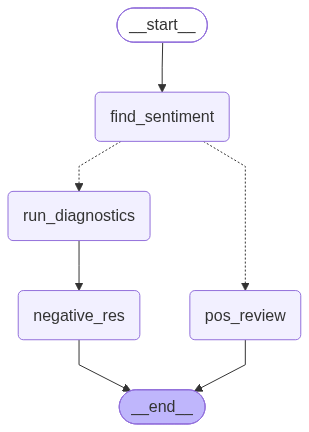

In [24]:
workflow

In [25]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': SentimentSchema(sentiment='negative'),
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': 'Subject: Resolution for Your High Priority Bug - [Briefly describe the bug, e.g., "Login Issue," "Data Loss," "System Crash"]\n\nHi [User\'s Name],\n\nI understand how incredibly frustrating it is to encounter a bug, especially when it\'s impacting your work and marked with high urgency. I sincerely apologize for the trouble and inconvenience this caused you.\n\nI\'m happy to report that we\'ve thoroughly investigated the issue you reported regarding [briefly restate the bug, e.g., "the unexpected logout behavior," "the error when saving your project," "the incorrect data display"]. We\'ve identified th